In [3]:
# Loading the Data that Arjun created

import pandas as pd
df = pd.read_csv("teamb_final_data.csv")

In [4]:
print(df.columns)

Index(['datetime', 'lat', 'lng', 'district', 'subject_age', 'violation',
       'violation_embedded', 'arrest_made', 'citation_issued',
       'search_conducted', 'speed', 'subject_race_black',
       'subject_race_hispanic', 'subject_race_other', 'subject_race_white',
       'subject_sex_male', 'extreme_cases', 'texas_sb_4_active',
       'sandra_bland_act_active', 'eo_13768_active', 'texas_sb_158_active',
       'texas_hb_3791_active', 'eo_13688_active', 'texas_hb_1036_active',
       'eo_13809_active', 'san_antonio_hands-free_ordinance_active',
       'texas_hb_3389_active', 'dhs_johnson_memo_active',
       'fy2017_byrne_justice_assistance_grant_(jag)_active',
       'maryland_v._wilson_active', 'eo_13773_active'],
      dtype='object')


In [5]:
len(df)

824051

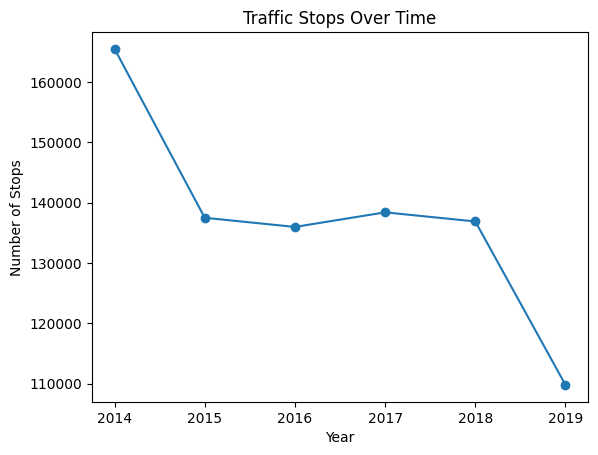

In [6]:
# Making some new simple plots

import pandas as pd
import matplotlib.pyplot as plt

df['datetime'] = pd.to_datetime(df['datetime'])

stops_by_year = df.groupby(df['datetime'].dt.year).size()

stops_by_year.plot(kind='line', marker='o')
plt.title("Traffic Stops Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Stops")
plt.show()

In [48]:
# Seeing what the top crimes are for people having extreme outcomes

import pandas as pd

race_cols = {
    "White": "subject_race_white",
    "Black": "subject_race_black",
    "Hispanic": "subject_race_hispanic"
}

results = []

for race, col in race_cols.items():
    temp = (
        df[df[col] == 1]
        .groupby('violation')
        .agg(
            total_stops=('extreme_cases', 'size'),
            extreme_outcomes=('extreme_cases', 'sum'),
            extreme_rate=('extreme_cases', 'mean')
        )
        .reset_index()
    )
    
    temp['Race'] = race
    results.append(temp)

violation_race_table = pd.concat(results)

# only keep violations with enough observations
violation_race_table = violation_race_table[violation_race_table['total_stops'] >= 100]

# pivot so races become columns
heatmap_table = violation_race_table.pivot(
    index='violation',
    columns='Race',
    values='extreme_rate'
)

# sort by Black rate descending
heatmap_table = heatmap_table.sort_values(by='Black', ascending=False)

heatmap_table.head(20)

Race,Black,Hispanic,White
violation,,,
IMPROPER RIGHT OR LEFT TURN - SIGNAL,0.129630,0.064073,0.076336
OPERATING A MOTOR VEHICLE WITHOUT A VALID LICENSE|FAILURE TO DISPLAY VALID REGISTRATION INSIGNIA (STICKER),0.128319,0.067010,0.097260
POSSESSION OF OPEN CONTAINER,0.106796,0.131818,0.166667
FAILURE TO DISPLAY VALID REGISTRATION INSIGNIA (STICKER)|DRIVING WITHOUT PROOF OF FINANCIAL RESPONSIBILITY,0.089202,0.060797,0.072386
DRIVING WITHOUT PROOF OF FINANCIAL RESPONSIBILITY|DRIVING WHILE LICENSE INVALID,0.076923,0.062500,0.079882
FAILURE TO DISPLAY VALID REGISTRATION INSIGNIA (STICKER)|OPERATING A MOTOR VEHICLE WITHOUT A VALID LICENSE,0.076503,0.063278,0.082671
OPERATING A MOTOR VEHICLE WITHOUT A VALID LICENSE|DRIVING WITHOUT PROOF OF FINANCIAL RESPONSIBILITY,0.072993,0.051427,0.059207
DRIVING WITHOUT PROOF OF FINANCIAL RESPONSIBILITY|FAILURE TO DISPLAY VALID REGISTRATION INSIGNIA (STICKER),0.064378,0.047983,0.074645
PEDESTRIAN ON ROADWAY NEXT TO SIDEWALK,0.063830,0.051095,0.052261


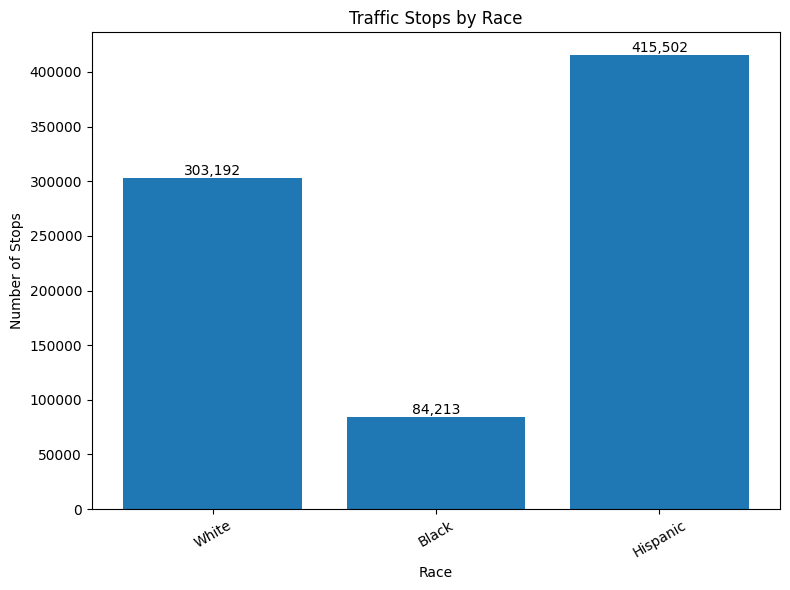

In [45]:
# Total Count by Race of stops

import matplotlib.pyplot as plt
import pandas as pd

race_counts = {
    "White": df['subject_race_white'].sum(),
    "Black": df['subject_race_black'].sum(),
    "Hispanic": df['subject_race_hispanic'].sum(),
}

race_series = pd.Series(race_counts)

plt.figure(figsize=(8,6))

bars = plt.bar(race_series.index, race_series.values)

plt.title("Traffic Stops by Race")
plt.xlabel("Race")
plt.ylabel("Number of Stops")

plt.xticks(rotation=30)

# add value labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{int(height):,}",
             ha='center',
             va='bottom')

plt.tight_layout()
plt.show()



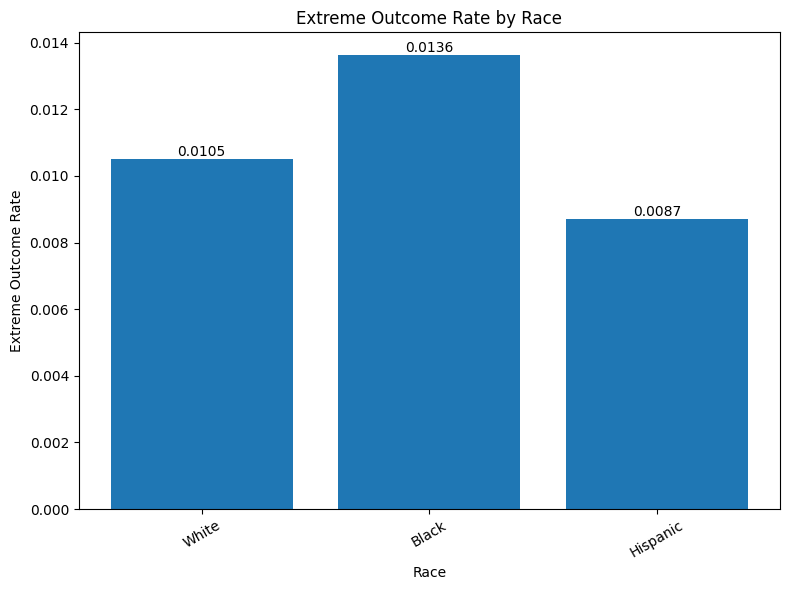

In [44]:
#Extreme Outcome by Race

import matplotlib.pyplot as plt
import pandas as pd

race_cols = {
    "White": "subject_race_white",
    "Black": "subject_race_black",
    "Hispanic": "subject_race_hispanic"
}

extreme_rates = {}

for race, col in race_cols.items():
    extreme_rates[race] = df[df[col] == 1]['extreme_cases'].mean()

plt.figure(figsize=(8,6))

bars = plt.bar(
    extreme_rates.keys(),
    extreme_rates.values()
)

plt.title("Extreme Outcome Rate by Race")
plt.ylabel("Extreme Outcome Rate")
plt.xlabel("Race")
plt.xticks(rotation=30)

# add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.4f}",
             ha='center',
             va='bottom')

plt.tight_layout()
plt.show()

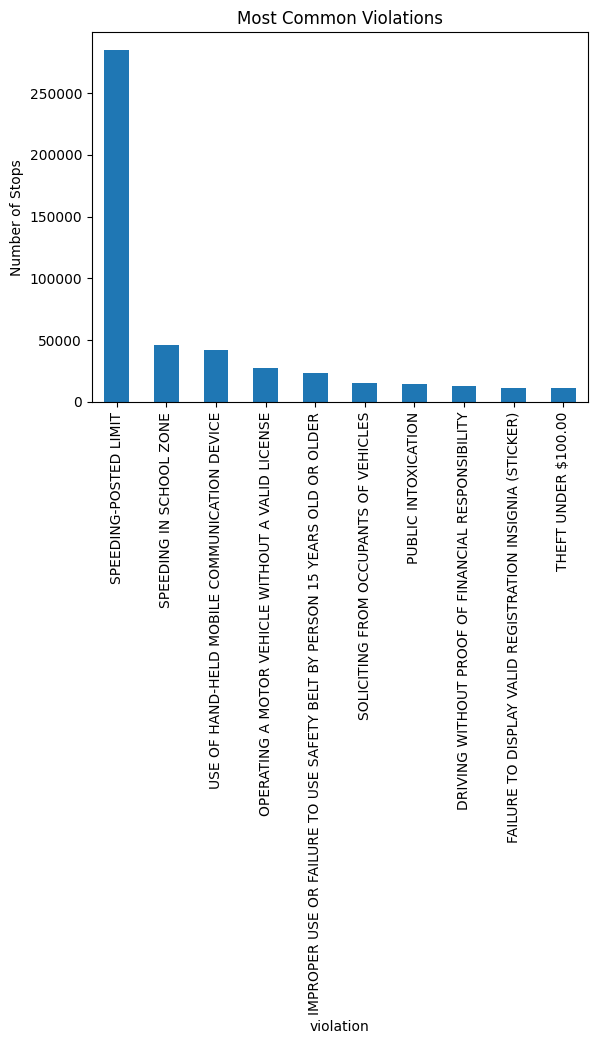

In [10]:
# Plotting Most Common Violations

top_violations = df['violation'].value_counts().head(10)

top_violations.plot(kind='bar')
plt.title("Most Common Violations")
plt.ylabel("Number of Stops")
plt.show()

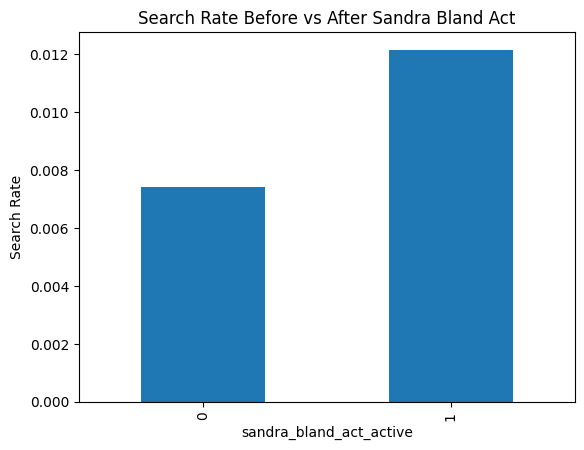

In [14]:
# Simple code for before and after difference of the Policy Changes

df.groupby('sandra_bland_act_active')['search_conducted'].mean().plot(kind='bar')
plt.title("Search Rate Before vs After Sandra Bland Act")
plt.ylabel("Search Rate")
plt.show()

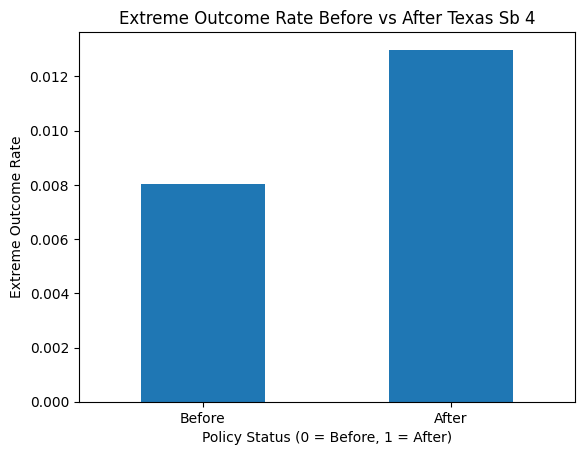

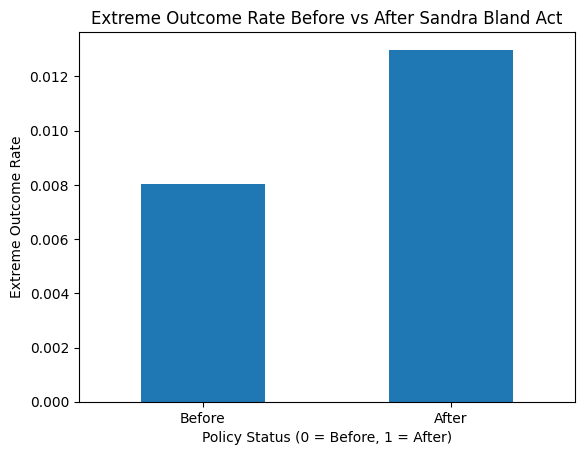

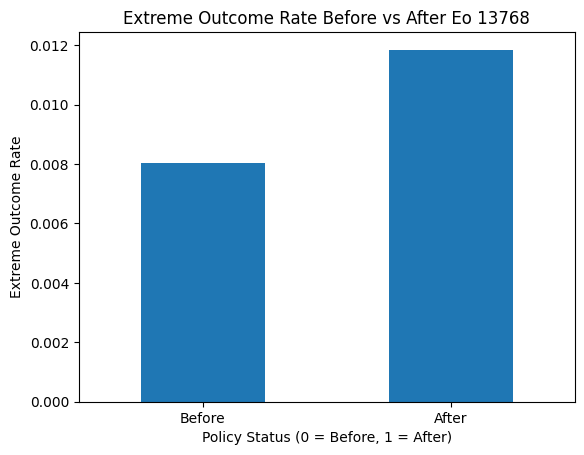

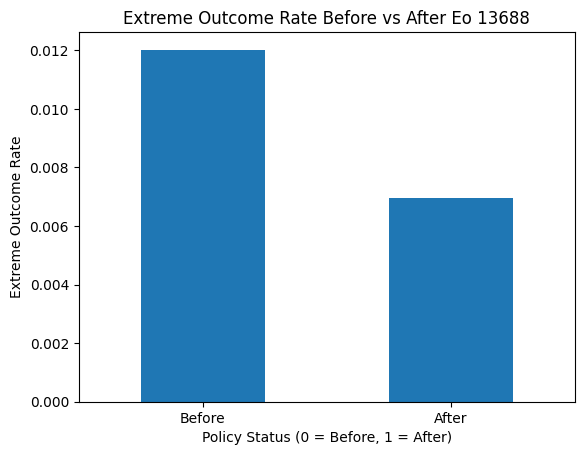

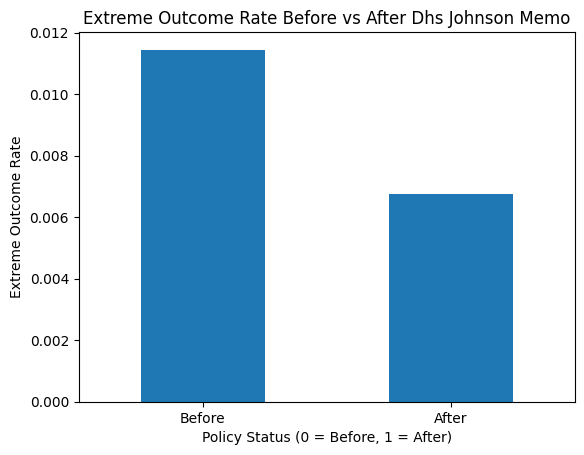

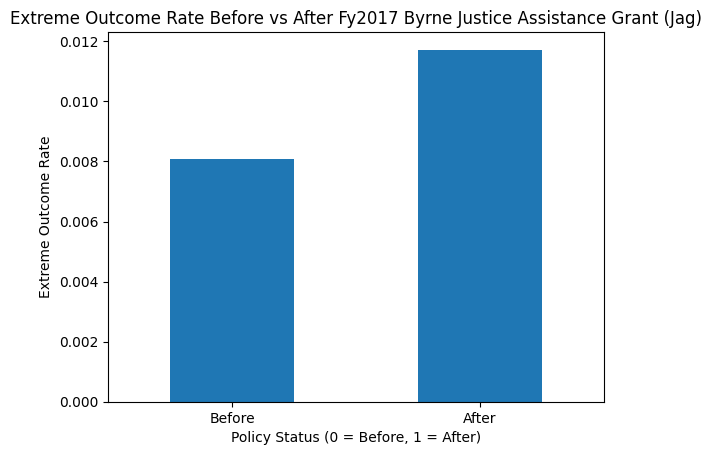

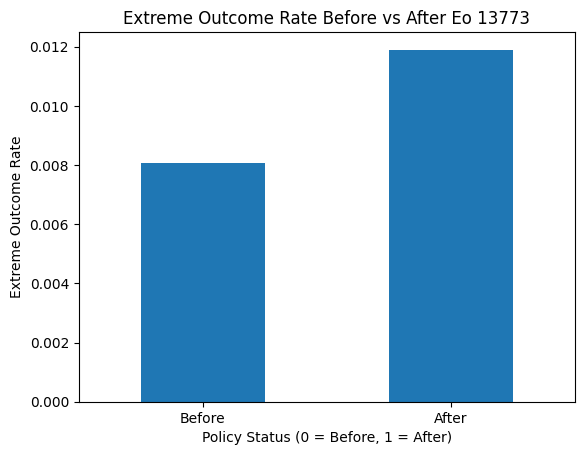

In [34]:
# Seeing the Overall before and after difference of all the Policy Changes

import matplotlib.pyplot as plt

#the ones i want to include: 
policies = [
    'texas_sb_4_active',
    'sandra_bland_act_active',
    'eo_13768_active',
    'eo_13688_active',
    'dhs_johnson_memo_active',
    'fy2017_byrne_justice_assistance_grant_(jag)_active',
    'eo_13773_active'
]

# grouping by policy
for policy in policies:
    df.groupby(policy)['extreme_cases'].mean().plot(kind='bar')

    plt.title(f"Extreme Outcome Rate Before vs After {policy.replace('_active','').replace('_',' ').title()}")
    plt.ylabel("Extreme Outcome Rate")
    plt.xlabel("Policy Status (0 = Before, 1 = After)")
    plt.xticks([0,1], ["Before", "After"], rotation=0)

    plt.show()

In [ ]:
#Now including Race in there

import matplotlib.pyplot as plt
import numpy as np

policies = [
    'texas_sb_4_active',
    'sandra_bland_act_active',
    'eo_13768_active',
    'eo_13688_active',
    'dhs_johnson_memo_active',
    'fy2017_byrne_justice_assistance_grant_(jag)_active',
    'eo_13773_active'
]

for policy in policies:

    black_rate = df[df['subject_race_black'] == 1].groupby(policy)['extreme_cases'].mean()
    hispanic_rate = df[df['subject_race_hispanic'] == 1].groupby(policy)['extreme_cases'].mean()
    white_rate = df[df['subject_race_white'] == 1].groupby(policy)['extreme_cases'].mean()

    before = [black_rate.get(0,0), hispanic_rate.get(0,0), white_rate.get(0,0)]
    after = [black_rate.get(1,0), hispanic_rate.get(1,0), white_rate.get(1,0)]

    races = ['Black','Hispanic','White']
    x = np.arange(len(races))
    width = 0.35

    plt.figure(figsize=(7,4))
    
    plt.bar(x - width/2, before, width, label='Before')
    plt.bar(x + width/2, after, width, label='After')

    plt.xticks(x, races)
    plt.ylabel("Extreme Outcome Rate")
    plt.title(f"Extreme Outcome Rate by Race\nBefore vs After {policy.replace('_active','').replace('_',' ').title()}")
    plt.legend()
    
    plt.show()

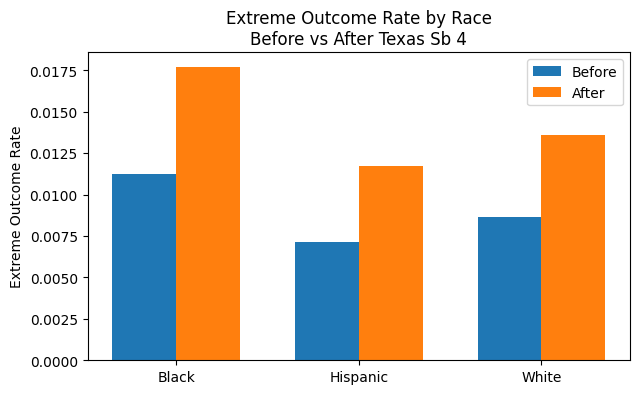

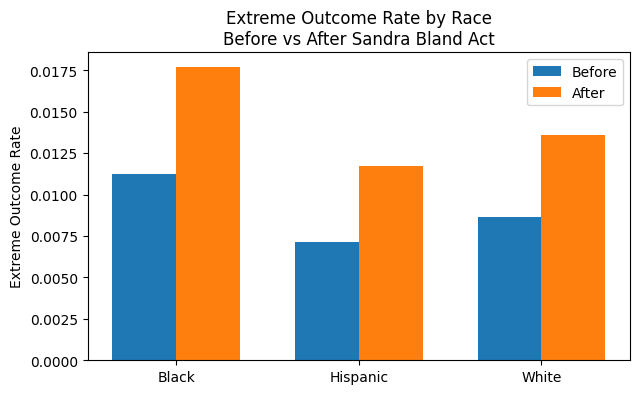

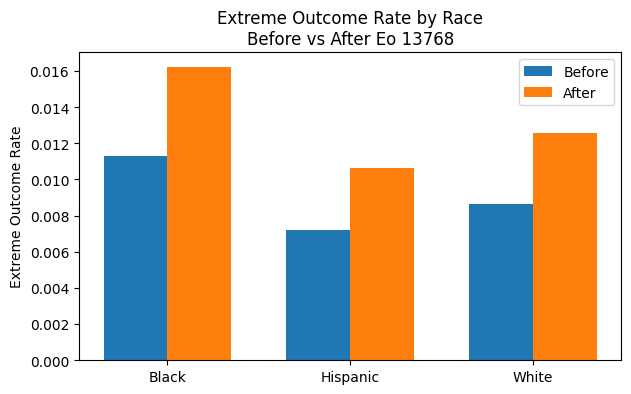

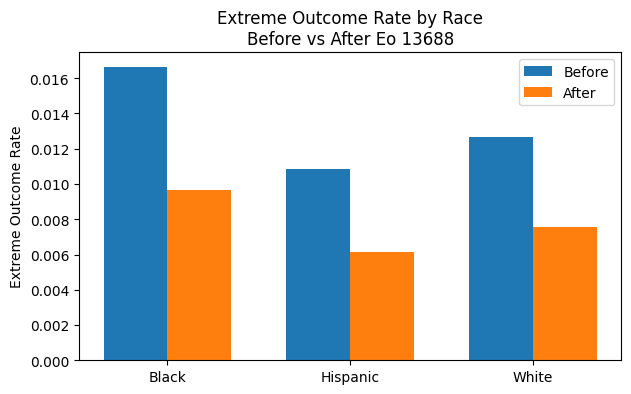

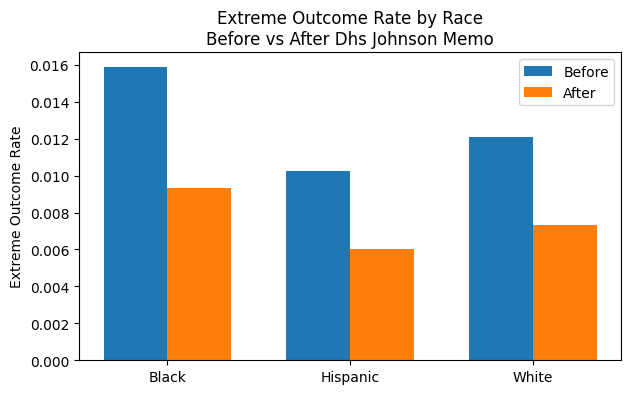

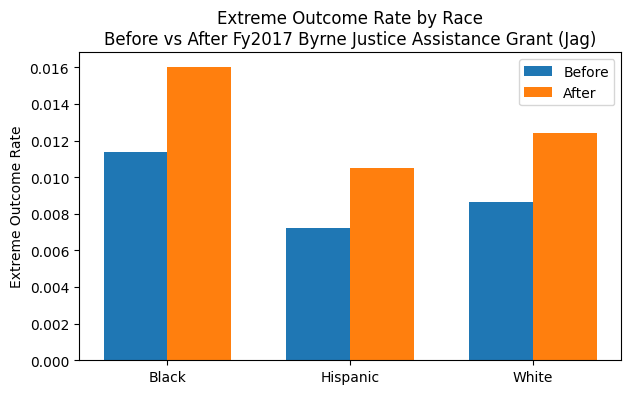

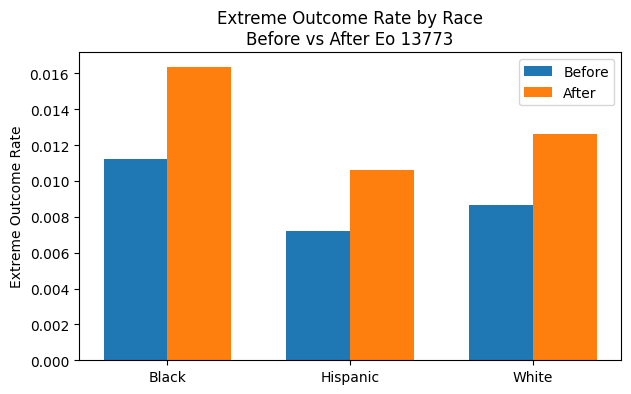

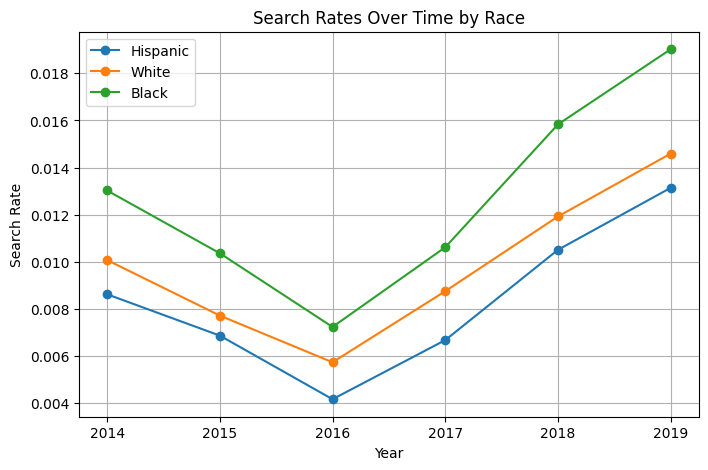

In [17]:
# Showing Simple line plot of search rates over time

import matplotlib.pyplot as plt

df['year'] = df['datetime'].dt.year

# Hispanic search rate
hispanic_search = df[df['subject_race_hispanic'] == 1].groupby('year')['search_conducted'].mean()

# White search rate
white_search = df[df['subject_race_white'] == 1].groupby('year')['search_conducted'].mean()

# Black search rate
black_search = df[df['subject_race_black'] == 1].groupby('year')['search_conducted'].mean()

plt.figure(figsize=(8,5))

plt.plot(hispanic_search.index, hispanic_search.values, marker='o', label="Hispanic")
plt.plot(white_search.index, white_search.values, marker='o', label="White")
plt.plot(black_search.index, black_search.values, marker='o', label="Black")

plt.title("Search Rates Over Time by Race")
plt.xlabel("Year")
plt.ylabel("Search Rate")
plt.legend()
plt.grid(True)

plt.show()

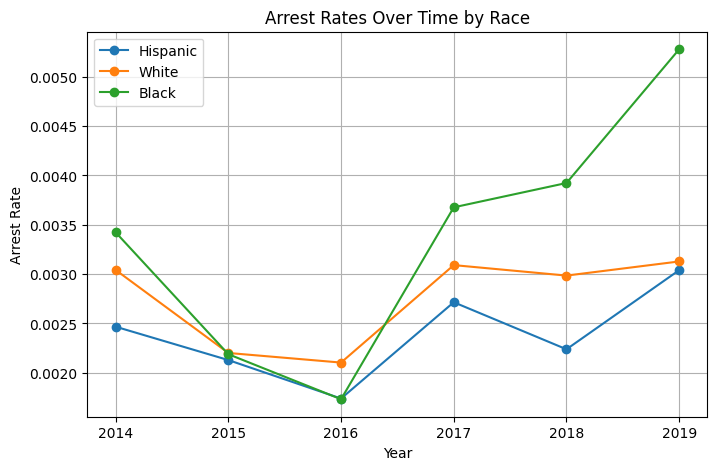

In [18]:
# Doing the same, but with arrest rate

import matplotlib.pyplot as plt

df['year'] = df['datetime'].dt.year

# Hispanic arrest rate
hispanic_arrest = df[df['subject_race_hispanic'] == 1].groupby('year')['arrest_made'].mean()

# White arrest rate
white_arrest = df[df['subject_race_white'] == 1].groupby('year')['arrest_made'].mean()

# Black arrest rate
black_arrest = df[df['subject_race_black'] == 1].groupby('year')['arrest_made'].mean()

plt.figure(figsize=(8,5))

plt.plot(hispanic_arrest.index, hispanic_arrest.values, marker='o', label="Hispanic")
plt.plot(white_arrest.index, white_arrest.values, marker='o', label="White")
plt.plot(black_arrest.index, black_arrest.values, marker='o', label="Black")

plt.title("Arrest Rates Over Time by Race")
plt.xlabel("Year")
plt.ylabel("Arrest Rate")
plt.legend()
plt.grid(True)

plt.show()

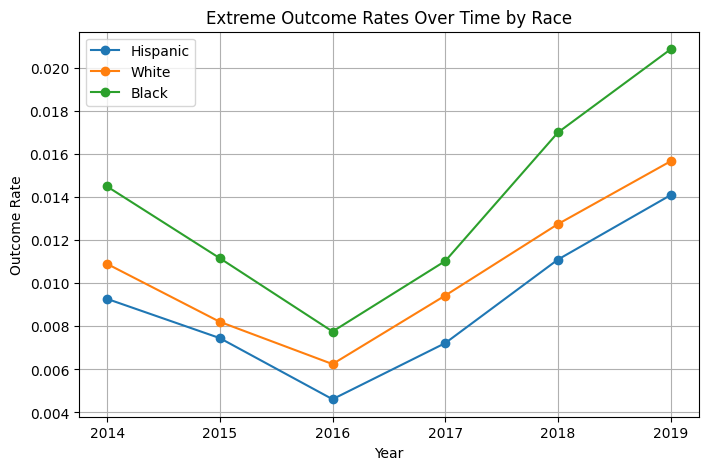

In [22]:
# Now for total extreme outcome rate by race

import matplotlib.pyplot as plt

df['year'] = df['datetime'].dt.year

# Hispanic 
hispanic_outcome = df[df['subject_race_hispanic'] == 1].groupby('year')['extreme_cases'].mean()

# White 
white_outcome = df[df['subject_race_white'] == 1].groupby('year')['extreme_cases'].mean()

# Black
black_outcome = df[df['subject_race_black'] == 1].groupby('year')['extreme_cases'].mean()

plt.figure(figsize=(8,5))

plt.plot(hispanic_outcome.index, hispanic_outcome.values, marker='o', label="Hispanic")
plt.plot(white_outcome.index, white_outcome.values, marker='o', label="White")
plt.plot(black_outcome.index, black_outcome.values, marker='o', label="Black")

plt.title("Extreme Outcome Rates Over Time by Race")
plt.xlabel("Year")
plt.ylabel("Outcome Rate")
plt.legend()
plt.grid(True)

plt.show()

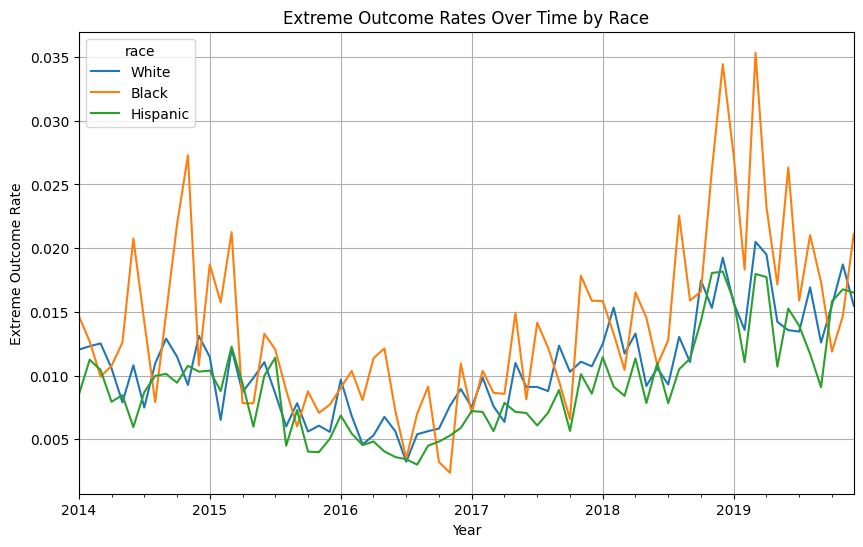

In [30]:
# Making same plot, but doing it by month to see more trends

import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime is correct
df['datetime'] = pd.to_datetime(df['datetime'])

# Create a single race column from one-hot encoded variables
df['race'] = 'Other'
df.loc[df['subject_race_white'] == 1, 'race'] = 'White'
df.loc[df['subject_race_black'] == 1, 'race'] = 'Black'
df.loc[df['subject_race_hispanic'] == 1, 'race'] = 'Hispanic'

# Create monthly time variable 
df['month'] = df['datetime'].dt.to_period('M')

# Calculate extreme outcome rates by race and month
outcome_time = df.groupby(['month', 'race'])['extreme_cases'].mean().unstack()

# Plot Hispanic, White, and Black
outcome_time[['White', 'Black', 'Hispanic']].plot(figsize=(10,6))

plt.title("Extreme Outcome Rates Over Time by Race")
plt.xlabel("Year")
plt.ylabel("Extreme Outcome Rate")
plt.grid(True)
plt.show()